# StructBERT: Domain-Adaptive Encoder for Data Structures & Algorithms

This notebook documents the end-to-end development of **StructBERT**,  
a BERT-based **encoder-only model** adapted to Data Structures & Algorithms (DSA) text using **Masked Language Modeling (MLM)**.

The focus is on **representation learning**, not generation.


## Motivation

General-purpose language models understand natural language well, but struggle with **algorithmic explanations**, **formal structure**, and **DSA terminology**.

This project explores whether **domain-adaptive pretraining** can improve:
- semantic similarity
- algorithmic understanding
- embedding quality for retrieval


## Project Scope

✔ Encoder-only (BERT)  
✔ Masked Language Modeling (MLM)  
✔ Custom DSA corpus  
✔ Embedding-based evaluation  

❌ No decoder training  
❌ No supervised QA fine-tuning


In [102]:
import torch
torch.cuda.is_available()
torch.cuda.get_device_name()

'Tesla P100-PCIE-16GB'

## Environment & Tools

- Platform: Kaggle
- Framework: PyTorch + Hugging Face Transformers + Tesla P100 gpu
- Base model: `bert-base-uncased`
- Tokenizer: WordPiece (BERT)


In [96]:
import pandas as pd
file = '/kaggle/working/data/mlm/dsa_corpus.txt'
df = pd.read_csv(file, delimiter='\t')
df.head(10)

,the algorithm design manual second edition
0,skiena the algorithm design manual second edit...
1,skiena departmentofcomputerscience stateuniver...
2,edu isbn 978 1 84800 069 8 e isbn 978 1 84800 ...
3,1007 978 1 84800 070 4 britishlibrarycatalogui...
4,enquiriesconcerningreproductionoutsidethoseter...
5,the use of registered names trademarks etc
6,in this publication does not imply even in the...
7,the publisher makes no representation express ...
8,printedonacid freepaper springerscience busine...
9,preface most professional programmers that i v...


In [ ]:
!pip install transformers datasets tokenizers --quiet

In [ ]:
!pip install pdfplumber


## Dataset Construction

In [5]:
import pdfplumber
from pathlib import Path

PDF_PATH = "/kaggle/input/algodesign/The Algorithm Design Manual by Steven S. Skiena.pdf"
OUTPUT_FILE = "data/mlm/algodesign_corpus.txt"

all_lines = []

with pdfplumber.open(PDF_PATH) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            sentences = [s.strip() for s in text.replace("\n", " ").split('.') if len(s.strip()) > 30]
            all_lines.extend(sentences)

Path(OUTPUT_FILE).parent.mkdir(exist_ok=True, parents=True)
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for line in all_lines:
        f.write(line + "\n")

print(f"Extracted {len(all_lines)} lines from PDF to {OUTPUT_FILE}")


✅ Extracted 13518 lines from PDF to data/mlm/algodesign_corpus.txt


In [ ]:
import os
import re
from pathlib import Path
import pdfplumber
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    BertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)

In [54]:
CORPUS_ALGODESIGN = "/kaggle/input/corpusdsa/algodesign_corpus.txt"
CORPUS_DSA = "/kaggle/input/corpusdsa/corpus.txt"
CORPUS_SEDGEWICK= "/kaggle/input/corpusdsa/sedgewick_corpus.txt"
MERGED_CORPUS = "/kaggle/working/data/mlm/dsa_corpus.txt"

In [56]:
words = open ('/kaggle/working/data/mlm/dsa_corpus.txt', 'r').read().splitlines()

In [57]:
words[:20]

['the algorithm design manual second edition',
 'skiena the algorithm design manual second edition 123',
 'skiena departmentofcomputerscience stateuniversityofnewyork atstonybrook newyork usa skiena cs',
 'edu isbn 978 1 84800 069 8 e isbn 978 1 84800 070 4 doi 10',
 '1007 978 1 84800 070 4 britishlibrarycataloguinginpublicationdata acataloguerecordforthisbookisavailablefromthebritishlibrary libraryofcongresscontrolnumber 2008931136 c springer verlaglondonlimited2008 apartfromanyfairdealingforthepurposesofresearchorprivatestudy orcriticismorreview aspermitted underthecopyright designsandpatentsact1988 thispublicationmayonlybereproduced storedortrans mitted inanyformorbyanymeans withthepriorpermissioninwritingofthepublishers orinthecaseof reprographicreproductioninaccordancewiththetermsoflicensesissuedbythecopyrightlicensingagency',
 'enquiriesconcerningreproductionoutsidethosetermsshouldbesenttothepublishers',
 'the use of registered names trademarks etc',
 'in this publication does no

In [58]:
len(words)

32852

In [59]:
min(len(word) for word in words)

13

In [8]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


## Text Normalization

Each line is:
- lowercased
- stripped of extra whitespace
- filtered by minimum length

The goal is **signal preservation**, not aggressive cleaning.


In [103]:
all_lines = []

for file in [CORPUS_ALGODESIGN, CORPUS_DSA, CORPUS_SEDGEWICK]:
    if os.path.exists(file):
        with open(file, "r", encoding="utf-8") as f:
            all_lines.extend([normalize(line) for line in f if len(line.strip()) > 20])

with open(MERGED_CORPUS, "w", encoding="utf-8") as f:
    for line in all_lines:
        f.write(line + "\n")

print(f"Merged corpus has {len(all_lines)} lines")

Merged corpus has 32852 lines


## Tokenization Strategy

- Tokenizer: `bert-base-uncased`
- WordPiece subword tokenization
- No truncation during tokenization
- Manual chunking into fixed-length sequences


In [10]:
dataset = load_dataset("text", data_files={"train": MERGED_CORPUS})
print(dataset)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 32852
    })
})


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [71]:
def tokenize_and_chunk(batch, chunk_size=128):
    all_input_ids = []

    for text in batch["text"]:
        tokens = tokenizer(
            text,
            truncation=False,
            add_special_tokens=True
        )["input_ids"]

        for i in range(0, len(tokens), chunk_size):
            chunk = tokens[i:i + chunk_size]
            if len(chunk) == chunk_size:
                all_input_ids.append(chunk)

    return {"input_ids": all_input_ids}


In [112]:
tokens = tokenized_dataset[0]["input_ids"]

print(type(tokens))          # <class 'list'>
print(len(tokens))           # should be 128
print(tokens[:50])


<class 'list'>
128
[101, 2531, 2581, 4891, 1015, 6391, 17914, 2692, 5718, 2692, 1018, 2329, 29521, 19848, 2100, 11266, 23067, 25698, 3070, 2378, 14289, 16558, 21261, 2850, 2696, 9353, 27815, 8649, 13094, 8586, 8551, 15628, 2483, 8654, 14268, 3567, 11733, 3468, 19699, 5358, 10760, 23736, 24788, 29521, 19848, 2100, 3075, 11253, 8663, 17603]


In [113]:
import torch

tokens_tensor = torch.tensor(tokens)

print(tokens_tensor.shape)   # torch.Size([128])
print(tokens_tensor.dtype)   # torch.int64
print(tokens_tensor[:50])


torch.Size([128])
torch.int64
tensor([  101,  2531,  2581,  4891,  1015,  6391, 17914,  2692,  5718,  2692,
         1018,  2329, 29521, 19848,  2100, 11266, 23067, 25698,  3070,  2378,
        14289, 16558, 21261,  2850,  2696,  9353, 27815,  8649, 13094,  8586,
         8551, 15628,  2483,  8654, 14268,  3567, 11733,  3468, 19699,  5358,
        10760, 23736, 24788, 29521, 19848,  2100,  3075, 11253,  8663, 17603])


In [115]:
print(tokenizer.vocab_size)
print(tokenizer.convert_ids_to_tokens(tokens[:30]))


30522
['[CLS]', '100', '##7', '978', '1', '84', '##80', '##0', '07', '##0', '4', 'british', '##lib', '##rar', '##y', '##cat', '##alo', '##gui', '##ng', '##in', '##pu', '##bl', '##ication', '##da', '##ta', 'ac', '##atal', '##og', '##uer', '##ec']


In [117]:
decoded_tokens = tokenizer.convert_ids_to_tokens(tokens)

print(decoded_tokens[:50])

print(tokenizer.decode(tokens, skip_special_tokens=True))


['[CLS]', '100', '##7', '978', '1', '84', '##80', '##0', '07', '##0', '4', 'british', '##lib', '##rar', '##y', '##cat', '##alo', '##gui', '##ng', '##in', '##pu', '##bl', '##ication', '##da', '##ta', 'ac', '##atal', '##og', '##uer', '##ec', '##ord', '##forth', '##is', '##book', '##isa', '##va', '##ila', '##ble', '##fr', '##om', '##the', '##bri', '##tish', '##lib', '##rar', '##y', 'library', '##of', '##con', '##gre']
1007 978 1 84800 070 4 britishlibrarycataloguinginpublicationdata acataloguerecordforthisbookisavailablefromthebritishlibrary libraryofcongresscontrolnumber 2008931136 c springer verlaglondonlimited2008 apartfromanyfairdealingforthepurposesofresearchorprivatestudy orcriticismorreview aspermitted underthecopyright designsandpatentsact1988 thispublicationmayonlybereproduced stored


In [109]:
tokens = tokenizer.convert_ids_to_tokens(sample)

print("Tokens:")
print(tokens)


Tokens:
['[CLS]', '100', '##7', '978', '1', '84', '##80', '##0', '07', '##0', '4', 'british', '##lib', '##rar', '##y', '##cat', '##alo', '##gui', '##ng', '##in', '##pu', '##bl', '##ication', '##da', '##ta', 'ac', '##atal', '##og', '##uer', '##ec', '##ord', '##forth', '##is', '##book', '##isa', '##va', '##ila', '##ble', '##fr', '##om', '##the', '##bri', '##tish', '##lib', '##rar', '##y', 'library', '##of', '##con', '##gre', '##ss', '##con', '##tro', '##ln', '##umber', '2008', '##9', '##31', '##13', '##6', 'c', 'springer', 'verlag', '##lon', '##don', '##lim', '##ited', '##200', '##8', 'apart', '##fr', '##oman', '##y', '##fa', '##ir', '##de', '##aling', '##forth', '##ep', '##ur', '##pose', '##so', '##fr', '##ese', '##ar', '##cho', '##rp', '##ri', '##vate', '##st', '##udy', 'or', '##cr', '##itic', '##ism', '##or', '##re', '##view', 'as', '##per', '##mit', '##ted', 'under', '##the', '##co', '##py', '##right', 'designs', '##and', '##pate', '##nts', '##act', '##19', '##8', '##8', 'this', '##p

In [110]:
decoded = tokenizer.decode(sample, skip_special_tokens=True)

print("Decoded text:")
print(decoded)


Decoded text:
1007 978 1 84800 070 4 britishlibrarycataloguinginpublicationdata acataloguerecordforthisbookisavailablefromthebritishlibrary libraryofcongresscontrolnumber 2008931136 c springer verlaglondonlimited2008 apartfromanyfairdealingforthepurposesofresearchorprivatestudy orcriticismorreview aspermitted underthecopyright designsandpatentsact1988 thispublicationmayonlybereproduced stored


In [80]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

batch = data_collator([tokenized_dataset[i] for i in range(4)])

for k, v in batch.items():
    print(k, v.shape)


input_ids torch.Size([4, 128])
attention_mask torch.Size([4, 128])
labels torch.Size([4, 128])


In [82]:
input_ids = batch["input_ids"]
labels = batch["labels"]

for i in range(4):
    print(f"\nSample {i}")
    for token_id, label_id in zip(input_ids[i], labels[i]):
        if label_id != -100:
            print(
                tokenizer.convert_ids_to_tokens([token_id.item()])[0],
                "→",
                tokenizer.convert_ids_to_tokens([label_id.item()])[0]
            )



Sample 0
[MASK] → 84
[MASK] → 07
[MASK] → ##ication
[MASK] → ##ta
[MASK] → ##ec
[MASK] → ##ila
[MASK] → ##tish
##lib → ##lib
[MASK] → ##y
[MASK] → 2008
[MASK] → ##ir
[MASK] → ##pose
[MASK] → ##udy
or → or
[MASK] → as
[MASK] → ##py
[MASK] → this
[MASK] → ##bl
##may → ##may
[MASK] → ##rod

Sample 1
[MASK] → design
ss → ss
suspense → rr
[MASK] → tt
[MASK] → n
[MASK] → e
[MASK] → t
[MASK] → i
[MASK] → n
mayhem → r
[MASK] → o
[MASK] → s
n → n
o → o
overlap → n
[MASK] → ##n
[MASK] → n
[MASK] → s
[MASK] → t
[MASK] → ee
[MASK] → n
rr → rr
[MASK] → i
##¹ → r
[MASK] → r
[MASK] → t
ee → ee
lang → n
[MASK] → ##n

Sample 2
attacking → ##are
pseudo → ##int
##aint → ##aint
[MASK] → ##qual
[MASK] → it
[MASK] → inequality
[MASK] → ##n
saddam → because
[MASK] → ##se
[MASK] → ##nd
[MASK] → ##n
[MASK] → ##2
[MASK] → 100
[MASK] → ##n
[MASK] → because
[MASK] → ##2
3 → 3
[MASK] → ##ose
##70 → ##n
[MASK] → ##ich
[MASK] → ##2

Sample 3
[MASK] → e
[MASK] → s
##mit → ee
[MASK] → ss
[MASK] → ss
[MASK] → o
[MASK]

In [83]:
print(batch["input_ids"].dtype)
print(batch["input_ids"].device)


torch.int64
cpu


In [87]:
import json

inspect_data = {
    "token_ids": sample,
    "tokens": tokens,
    "decoded": decoded
}

with open("/kaggle/working/token_inspect.json", "w") as f:
    json.dump(inspect_data, f, indent=2)

print("Token inspection saved")


Token inspection saved


In [85]:
unique_tokens = set(sample)
print("Unique tokens in sample:", len(unique_tokens))

unk_id = tokenizer.unk_token_id
print("UNK count:", sample.count(unk_id))


Unique tokens in sample: 112
UNK count: 0


In [12]:
tokenized_dataset = dataset["train"].map(
    tokenize_and_chunk,
    batched=True,
    remove_columns=["text"]
)

print("Tokenized and chunked dataset")
print(tokenized_dataset)

Map:   0%|          | 0/32852 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (535 > 512). Running this sequence through the model will result in indexing errors


✅ Tokenized and chunked dataset
Dataset({
    features: ['input_ids'],
    num_rows: 1033
})


In [13]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

In [14]:
print(tokenized_dataset)
print("Sample input_ids length:", len(tokenized_dataset[0]["input_ids"]))


Dataset({
    features: ['input_ids'],
    num_rows: 1033
})
Sample input_ids length: 128


In [15]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

print("MLM Data Collator ready")


✅ MLM Data Collator ready


## Masked Language Modeling (MLM)

- Mask probability: 15%
- Dynamic masking during training
- Special tokens preserved

This encourages learning algorithmic language patterns.


In [16]:
model = BertForMaskedLM.from_pretrained("bert-base-uncased")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/kaggle/working/structbert_mlm",
    overwrite_output_dir=True,

    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,

    num_train_epochs=10,
    learning_rate=2e-5,
    warmup_steps=100,

    logging_strategy="steps",t
    logging_steps=1,

    save_steps=500,
    save_total_limit=2,

    fp16=True,
    report_to="none",
)


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

print("🚀 Trainer initialized")


🚀 Trainer initialized


In [62]:
trainer.train()


Step,Training Loss
1,2.497400
2,2.258400
3,2.531100
4,2.167700
5,2.407300
6,2.216600
7,2.210000
8,2.569100
9,2.563800
10,2.269400


TrainOutput(global_step=330, training_loss=2.007277890407678, metrics={'train_runtime': 156.3508, 'train_samples_per_second': 66.069, 'train_steps_per_second': 2.111, 'total_flos': 679726429056000.0, 'train_loss': 2.007277890407678, 'epoch': 10.0})

In [63]:
logs = trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])


## Visualization

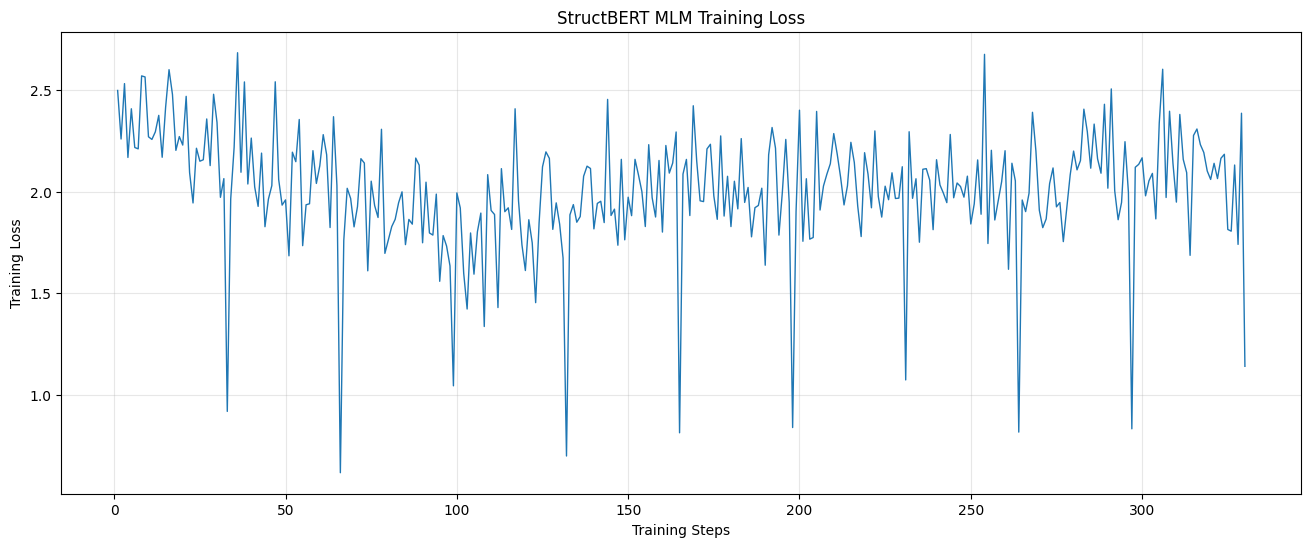

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.plot(steps, losses, linewidth=1)
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.title("StructBERT MLM Training Loss")
plt.grid(True, alpha=0.3)
plt.show()


In [69]:
np.mean(losses)

2.0072778787878787

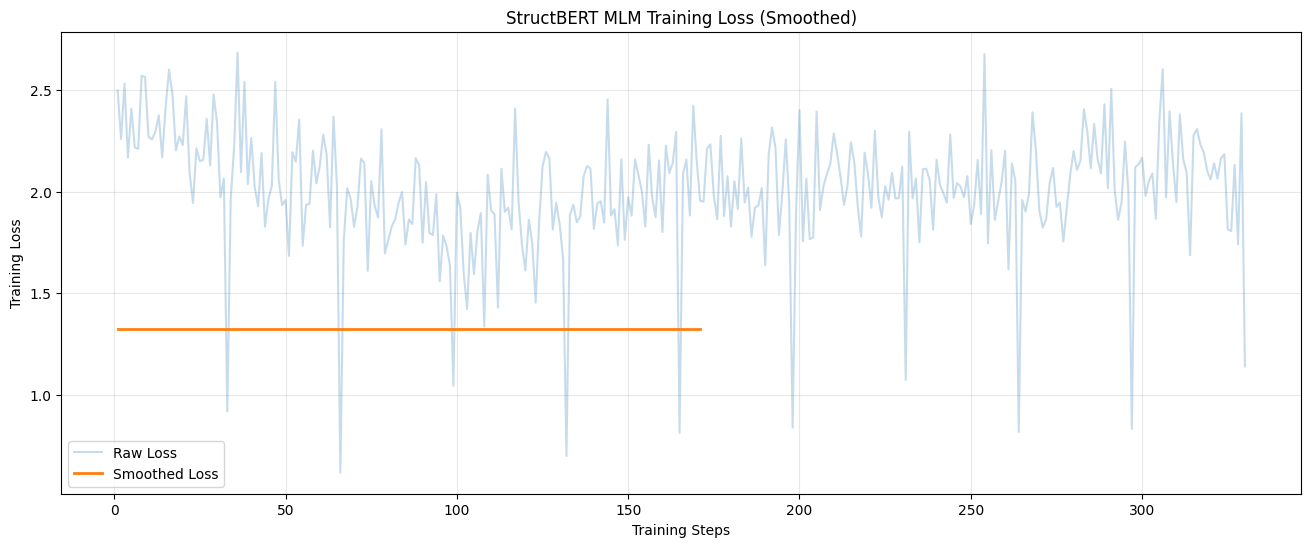

In [81]:
import numpy as np

def moving_average(x, window=500):
    return np.convolve(x, np.ones(window)/window, mode="valid")

smoothed_loss = moving_average(losses, window=500)
smoothed_steps = steps[:len(smoothed_loss)]

plt.figure(figsize=(16,6))
plt.plot(steps, losses, alpha=0.25, label="Raw Loss")
plt.plot(smoothed_steps, smoothed_loss, linewidth=2, label="Smoothed Loss")
plt.xlabel("Training Steps")
plt.ylabel("Training Loss")
plt.title("StructBERT MLM Training Loss (Smoothed)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [52]:
import torch
from torch.nn.functional import cosine_similarity

def embed(text):
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        return model.bert(**inputs).last_hidden_state[:, 0, :]

e1 = embed("prefix sum range query algorithm")
e2 = embed("range sum query using prefix array")
e3 = embed("binary search tree rotations")

print("similar:", cosine_similarity(e1, e2).item())
print("different:", cosine_similarity(e1, e3).item())


similar: 0.7722271680831909
different: 0.3584645986557007


In [88]:
trainer.save_model("/kaggle/working/structbert_encoder")
tokenizer.save_pretrained("/kaggle/working/structbert_encoder")

print("StructBERT encoder saved")


StructBERT encoder saved


In [ ]:
from transformers import BertTokenizer, BertForMaskedLM

MODEL_PATH = "/kaggle/working/structbert_encoder"

model.save_pretrained(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)


In [ ]:
!pip install huggingface_hub --quiet

from huggingface_hub import login
login(token="")


In [93]:
from huggingface_hub import login, upload_folder

upload_folder(folder_path="/kaggle/working/structbert_encoder", repo_id="Saif10/StructBERT-encoder", repo_type="model")


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Saif10/StructBERT-encoder/commit/6f08a9b4808655c89bd0ab51f698848c4134eca3', commit_message='Upload folder using huggingface_hub', commit_description='', oid='6f08a9b4808655c89bd0ab51f698848c4134eca3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Saif10/StructBERT-encoder', endpoint='https://huggingface.co', repo_type='model', repo_id='Saif10/StructBERT-encoder'), pr_revision=None, pr_num=None)

In [94]:
from transformers import BertTokenizer, BertForMaskedLM

tokenizer = BertTokenizer.from_pretrained("Saif10/StructBERT-encoder")
model = BertForMaskedLM.from_pretrained("Saif10/StructBERT-encoder")

text = "Binary search works by dividing the [MASK] into two halves."

inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
predicted_token_id = outputs.logits.argmax(-1)
predicted_token = tokenizer.decode(predicted_token_id[0])

print(predicted_token)

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

the binary search works by dividing the data into two halves .9
